# Explain/Eval Aggregation EDA

This notebook loads the aggregated explain/evaluate outputs for one run, then plots feature importance, client-level metrics, and client divergence summaries.

Run from the repository root. If `matplotlib` is missing in the notebook environment, install it in that environment before running the plotting cells.

In [3]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "matplotlib is required for this notebook. Install it in the active notebook environment."
    ) from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.style.use("default")

## Configure Input

In [5]:
RUN_ID = "federated-training-adult_income-20260425t104914724397+0000-logistic_regression-10clients-alpha1.0-seed42-440dd6719dc4"
SELECTION_ID = "test__max-10__seed-42"
EXPLAINER = "lime"
CONFIG_ID = "lime__kernel-1.5__samples-50"

BASE_DIR = (
    Path("../federated")
    / "runs"
    / RUN_ID
    / "aggregations"
    / "explain_eval"
    / SELECTION_ID
    / EXPLAINER
    / CONFIG_ID
)

if not BASE_DIR.exists():
    raise FileNotFoundError(f"Aggregation directory does not exist: {BASE_DIR}")

BASE_DIR

PosixPath('../federated/runs/federated-training-adult_income-20260425t104914724397+0000-logistic_regression-10clients-alpha1.0-seed42-440dd6719dc4/aggregations/explain_eval/test__max-10__seed-42/lime/lime__kernel-1.5__samples-50')

## Load Aggregated Tables

In [6]:
with (BASE_DIR / "aggregation_metadata.json").open("r", encoding="utf-8") as handle:
    metadata = json.load(handle)

instance_metrics = pd.read_parquet(BASE_DIR / "instance_metrics.parquet")
job_metrics = pd.read_parquet(BASE_DIR / "job_metrics.parquet")
explanations_long = pd.read_parquet(BASE_DIR / "explanations_long.parquet")
feature_by_client = pd.read_parquet(BASE_DIR / "feature_importance_by_client.parquet")
client_metrics = pd.read_parquet(BASE_DIR / "client_metric_summary.parquet")
divergence = pd.read_parquet(BASE_DIR / "divergence_summary.parquet")

summary = pd.DataFrame(
    [
        {"table": "instance_metrics", "rows": len(instance_metrics), "columns": instance_metrics.shape[1]},
        {"table": "job_metrics", "rows": len(job_metrics), "columns": job_metrics.shape[1]},
        {"table": "explanations_long", "rows": len(explanations_long), "columns": explanations_long.shape[1]},
        {"table": "feature_by_client", "rows": len(feature_by_client), "columns": feature_by_client.shape[1]},
        {"table": "client_metrics", "rows": len(client_metrics), "columns": client_metrics.shape[1]},
        {"table": "divergence", "rows": len(divergence), "columns": divergence.shape[1]},
    ]
)
display(summary)
display({k: metadata[k] for k in ["client_count", "shard_job_count", "instance_count", "explanation_feature_row_count"]})

,table,rows,columns
0,instance_metrics,100,37
1,job_metrics,20,13
2,explanations_long,10500,22
3,feature_by_client,1050,14
4,client_metrics,10,121
5,divergence,45,10


{'client_count': 10,
 'shard_job_count': 20,
 'instance_count': 100,
 'explanation_feature_row_count': 10500}

## Top Global Features

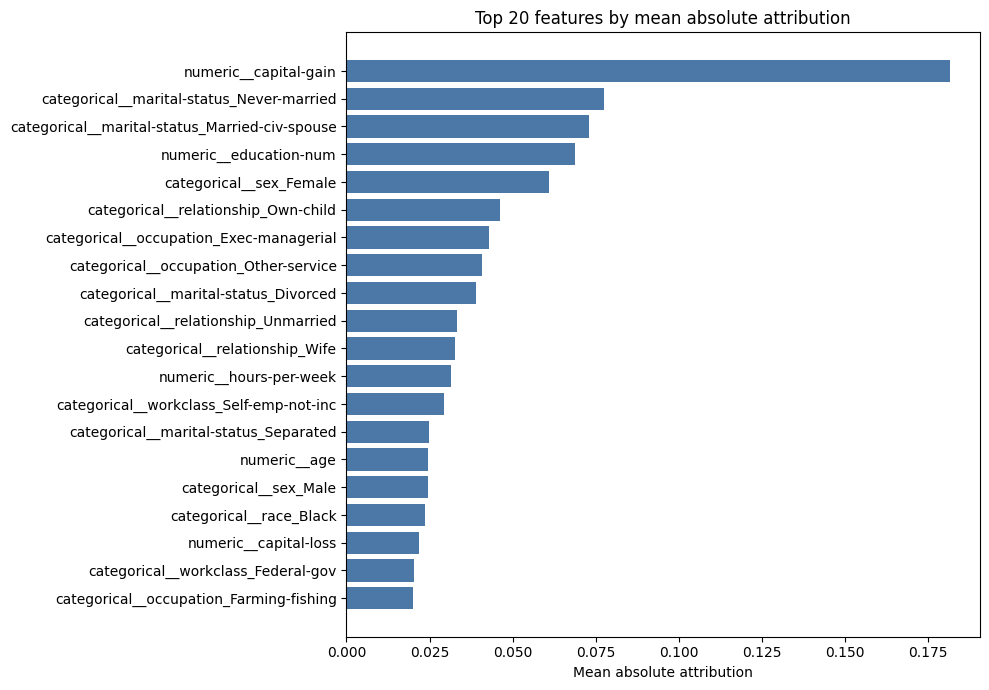

,feature_name,mean_abs_attribution,mean_signed_attribution,client_count
0,numeric__capital-gain,0.181658,0.181658,10
1,categorical__marital-status_Never-married,0.077627,-0.077627,10
2,categorical__marital-status_Married-civ-spouse,0.073018,0.073018,10
3,numeric__education-num,0.068832,0.068832,10
4,categorical__sex_Female,0.061057,-0.061057,10
5,categorical__relationship_Own-child,0.046260,-0.046260,10
6,categorical__occupation_Exec-managerial,0.042811,0.042811,10
7,categorical__occupation_Other-service,0.040737,-0.040737,10
8,categorical__marital-status_Divorced,0.039126,-0.039126,10
9,categorical__relationship_Unmarried,0.033380,-0.033380,10


In [7]:
top_n = 20
global_features = (
    feature_by_client.groupby("feature_name", as_index=False)
    .agg(
        mean_abs_attribution=("mean_abs_attribution", "mean"),
        mean_signed_attribution=("mean_attribution", "mean"),
        client_count=("client_id", "nunique"),
    )
    .sort_values("mean_abs_attribution", ascending=False)
    .head(top_n)
    .sort_values("mean_abs_attribution", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(global_features["feature_name"], global_features["mean_abs_attribution"], color="#4c78a8")
ax.set_title(f"Top {top_n} features by mean absolute attribution")
ax.set_xlabel("Mean absolute attribution")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

display(global_features.sort_values("mean_abs_attribution", ascending=False).reset_index(drop=True))

## Client-Feature Heatmap

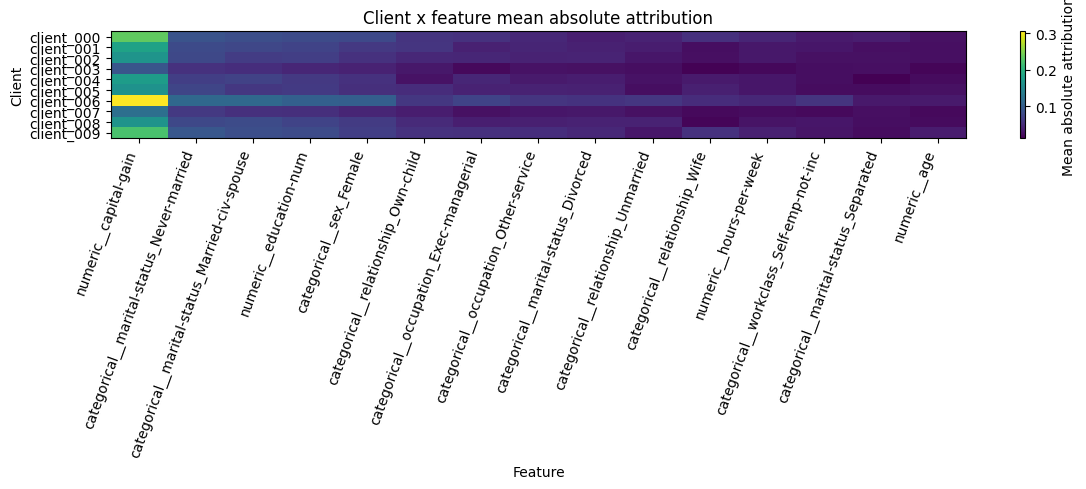

In [8]:
heatmap_features = (
    feature_by_client.groupby("feature_name")["mean_abs_attribution"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

heatmap = (
    feature_by_client[feature_by_client["feature_name"].isin(heatmap_features)]
    .pivot_table(
        index="client_id",
        columns="feature_name",
        values="mean_abs_attribution",
        aggfunc="mean",
        fill_value=0.0,
    )
    .loc[:, list(heatmap_features)]
)

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(heatmap.to_numpy(), aspect="auto", cmap="viridis")
ax.set_title("Client x feature mean absolute attribution")
ax.set_xlabel("Feature")
ax.set_ylabel("Client")
ax.set_xticks(np.arange(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns, rotation=70, ha="right")
ax.set_yticks(np.arange(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
fig.colorbar(image, ax=ax, label="Mean absolute attribution")
fig.tight_layout()
plt.show()

## Client-Level Metric Bars

,available_metric_mean_columns
0,infidelity__mean
1,confidence__mean
2,continuity_stability__mean
3,correctness__mean
4,compactness_sparsity__mean
5,relative_input_stability__mean


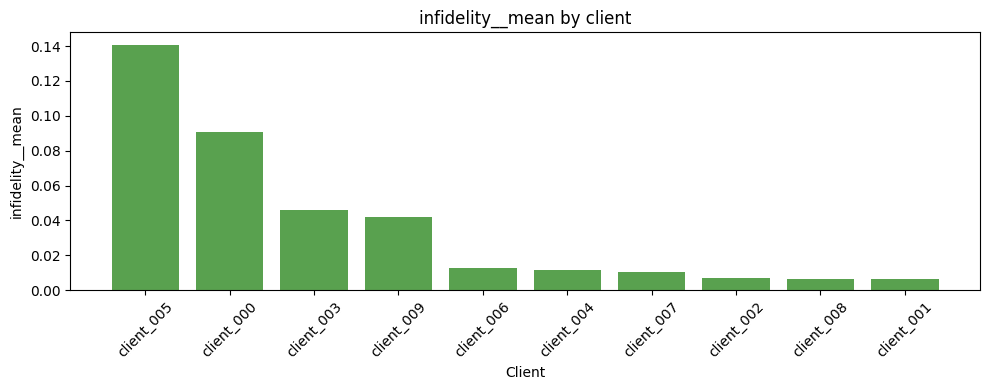

,client_id,infidelity__mean
0,client_005,0.140831
1,client_000,0.090886
2,client_003,0.046082
3,client_009,0.041786
4,client_006,0.012593
5,client_004,0.011421
6,client_007,0.010651
7,client_002,0.007110
8,client_008,0.006666
9,client_001,0.006491


In [9]:
candidate_metrics = [
    "infidelity",
    "confidence",
    "continuity_stability",
    "correctness",
    "compactness_sparsity",
    "relative_input_stability",
]
available_metric_means = [f"{metric}__mean" for metric in candidate_metrics if f"{metric}__mean" in client_metrics.columns]
display(pd.DataFrame({"available_metric_mean_columns": available_metric_means}))

metric_column = available_metric_means[0]
metric_by_client = client_metrics[["client_id", metric_column]].sort_values(metric_column, ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(metric_by_client["client_id"], metric_by_client[metric_column], color="#59a14f")
ax.set_title(f"{metric_column} by client")
ax.set_xlabel("Client")
ax.set_ylabel(metric_column)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

display(metric_by_client.reset_index(drop=True))

## Metric Distribution Across Instances

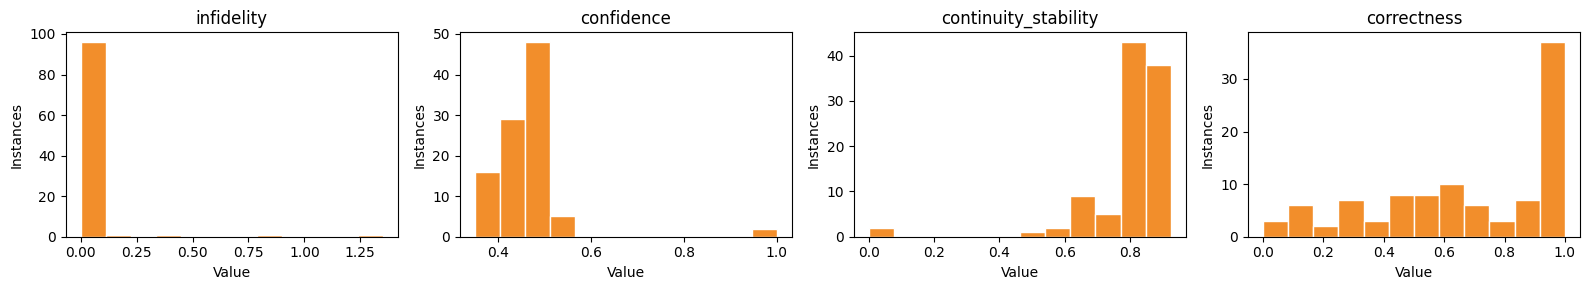

In [10]:
metric_columns = [metric for metric in candidate_metrics if metric in instance_metrics.columns]
metric_columns = metric_columns[:4]

fig, axes = plt.subplots(1, len(metric_columns), figsize=(4 * len(metric_columns), 3), squeeze=False)
for ax, metric in zip(axes[0], metric_columns, strict=True):
    ax.hist(instance_metrics[metric].dropna(), bins=12, color="#f28e2b", edgecolor="white")
    ax.set_title(metric)
    ax.set_xlabel("Value")
    ax.set_ylabel("Instances")
fig.tight_layout()
plt.show()

## Client Divergence

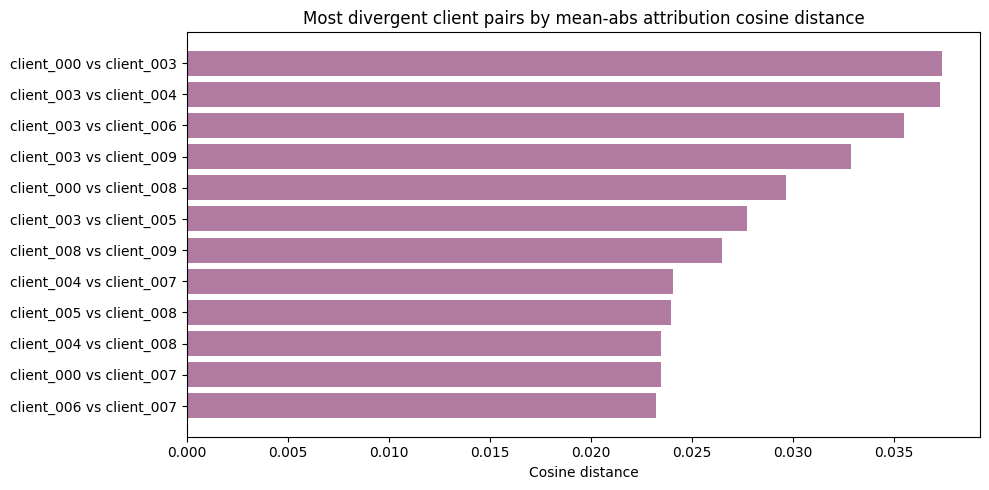

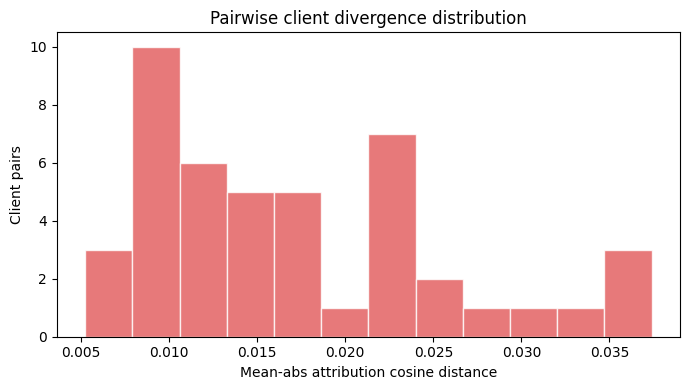

,run_id,selection_id,explainer_name,config_id,client_a,client_b,feature_count,mean_abs_cosine_distance,mean_abs_jensen_shannon,signed_cosine_distance,client_pair
0,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_000,client_003,105,0.037394,0.024581,0.053539,client_000 vs client_003
1,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_003,client_004,105,0.037265,0.023082,0.046784,client_003 vs client_004
2,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_003,client_006,105,0.035515,0.022773,0.047568,client_003 vs client_006
3,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_003,client_009,105,0.032902,0.016743,0.037334,client_003 vs client_009
4,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_000,client_008,105,0.029647,0.025416,0.037400,client_000 vs client_008
5,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_003,client_005,105,0.027752,0.018967,0.037565,client_003 vs client_005
6,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_008,client_009,105,0.026500,0.020714,0.029260,client_008 vs client_009
7,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_004,client_007,105,0.024063,0.031845,0.029483,client_004 vs client_007
8,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_005,client_008,105,0.023950,0.022140,0.027363,client_005 vs client_008
9,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_004,client_008,105,0.023496,0.022405,0.027712,client_004 vs client_008


In [11]:
divergence_sorted = divergence.sort_values("mean_abs_cosine_distance", ascending=False).copy()
divergence_sorted["client_pair"] = divergence_sorted["client_a"] + " vs " + divergence_sorted["client_b"]
top_pairs = divergence_sorted.head(12).sort_values("mean_abs_cosine_distance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_pairs["client_pair"], top_pairs["mean_abs_cosine_distance"], color="#b07aa1")
ax.set_title("Most divergent client pairs by mean-abs attribution cosine distance")
ax.set_xlabel("Cosine distance")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(divergence["mean_abs_cosine_distance"].dropna(), bins=12, color="#e15759", edgecolor="white", alpha=0.8)
ax.set_title("Pairwise client divergence distribution")
ax.set_xlabel("Mean-abs attribution cosine distance")
ax.set_ylabel("Client pairs")
fig.tight_layout()
plt.show()

display(divergence_sorted.head(12).reset_index(drop=True))

## Tables For Downstream Inspection

In [12]:
display(client_metrics.head(10))
display(feature_by_client.sort_values("mean_abs_attribution", ascending=False).head(20))
display(instance_metrics.head(10))

,run_id,selection_id,explainer_name,config_id,client_id,instance_count,compactness_effective_features__mean,compactness_effective_features__std,compactness_effective_features__median,compactness_effective_features__min,compactness_effective_features__max,compactness_sparsity__mean,compactness_sparsity__std,compactness_sparsity__median,compactness_sparsity__min,compactness_sparsity__max,compactness_top10_coverage__mean,compactness_top10_coverage__std,compactness_top10_coverage__median,compactness_top10_coverage__min,compactness_top10_coverage__max,compactness_top5_coverage__mean,compactness_top5_coverage__std,compactness_top5_coverage__median,compactness_top5_coverage__min,compactness_top5_coverage__max,completeness_drop__mean,completeness_drop__std,completeness_drop__median,completeness_drop__min,completeness_drop__max,completeness_random_drop__mean,completeness_random_drop__std,completeness_random_drop__median,completeness_random_drop__min,completeness_random_drop__max,completeness_score__mean,completeness_score__std,completeness_score__median,completeness_score__min,completeness_score__max,confidence__mean,confidence__std,confidence__median,confidence__min,confidence__max,consistency__mean,consistency__std,consistency__median,consistency__min,consistency__max,continuity_stability__mean,continuity_stability__std,continuity_stability__median,continuity_stability__min,continuity_stability__max,contrastivity__mean,contrastivity__std,contrastivity__median,contrastivity__min,...,contrastivity_pairs__mean,contrastivity_pairs__std,contrastivity_pairs__median,contrastivity_pairs__min,contrastivity_pairs__max,correctness__mean,correctness__std,correctness__median,correctness__min,correctness__max,covariate_complexity__mean,covariate_complexity__std,covariate_complexity__median,covariate_complexity__min,covariate_complexity__max,covariate_regularity__mean,covariate_regularity__std,covariate_regularity__median,covariate_regularity__min,covariate_regularity__max,infidelity__mean,infidelity__std,infidelity__median,infidelity__min,infidelity__max,monotonicity__mean,monotonicity__std,monotonicity__median,monotonicity__min,monotonicity__max,non_sensitivity_delta_mean__mean,non_sensitivity_delta_mean__std,non_sensitivity_delta_mean__median,non_sensitivity_delta_mean__min,non_sensitivity_delta_mean__max,non_sensitivity_safe_fraction__mean,non_sensitivity_safe_fraction__std,non_sensitivity_safe_fraction__median,non_sensitivity_safe_fraction__min,non_sensitivity_safe_fraction__max,non_sensitivity_violation_fraction__mean,non_sensitivity_violation_fraction__std,non_sensitivity_violation_fraction__median,non_sensitivity_violation_fraction__min,non_sensitivity_violation_fraction__max,non_sensitivity_zero_features__mean,non_sensitivity_zero_features__std,non_sensitivity_zero_features__median,non_sensitivity_zero_features__min,non_sensitivity_zero_features__max,output_completeness_deletion__mean,output_completeness_deletion__std,output_completeness_deletion__median,output_completeness_deletion__min,output_completeness_deletion__max,relative_input_stability__mean,relative_input_stability__std,relative_input_stability__median,relative_input_stability__min,relative_input_stability__max
0,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_000,10,0.705596,0.040064,0.719180,0.653074,0.752941,0.025714,0.037036,0.009524,0.0,0.095238,0.428825,0.037041,0.428331,0.381417,0.478665,0.287800,0.025944,0.300415,0.245608,0.315416,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.427658,0.033487,0.439220,0.374012,0.470300,0.0,0.0,0.0,0.0,0.0,0.761355,0.081782,0.781453,0.627888,0.870198,0.612310,0.211833,0.573932,0.351462,...,3.0,0.000000,3.0,3.0,3.0,0.510415,0.335636,0.381629,1.030232e-01,1.0,0.843349,0.017755,0.840213,0.823995,0.874498,0.156651,0.017755,0.159787,0.125502,0.176005,0.090886,0.277842,0.003252,0.000720,0.881629,0.751071,0.025903,0.749019,0.71

,run_id,selection_id,explainer_name,config_id,client_id,feature_index,feature_name,instance_count,mean_attribution,std_attribution,mean_abs_attribution,max_abs_attribution,positive_fraction,negative_fraction
633,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_006,3,numeric__capital-gain,10,0.305684,0.162574,0.305684,0.496224,1.0,0.0
3,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_000,3,numeric__capital-gain,10,0.234482,0.155288,0.234482,0.387158,1.0,0.0
948,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_009,3,numeric__capital-gain,10,0.221148,0.224826,0.221148,0.477215,0.9,0.1
108,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_001,3,numeric__capital-gain,10,0.181665,0.164646,0.181665,0.396658,1.0,0.0
423,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_004,3,numeric__capital-gain,10,0.173936,0.206518,0.173936,0.482338,1.0,0.0
213,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_002,3,numeric__capital-gain,10,0.164723,0.125340,0.164723,0.392161,1.0,0.0
843,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_008,3,numeric__capital-gain,10,0.162683,0.170985,0.162683,0.440608,1.0,0.0
528,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_005,3,numeric__capital-gain,10,0.162194,0.192118,0.162194,0.496549,1.0,0.0
738,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_007,3,numeric__capital-gain,10,0.120031,0.137057,0.120031,0.416121,1.0,0.0
662,federated-training-adult_income-20260425t10491...,test__max-10__seed-42,lime,lime__kernel-1.5__samples-50,client_006,32,categorical__marital-status_Married-civ-spouse,10,0.111795,0.081901,0.111795,0.250390,1.0,0.0


,run_id,client_id,split,selection_id,shard_id,explainer_name,config_id,instance_id,dataset_index,instance_index_within_job,true_label,prediction,explained_class,method_variant,compactness_sparsity,compactness_top5_coverage,compactness_top10_coverage,compactness_effective_features,completeness_drop,completeness_random_drop,completeness_score,confidence,consistency,continuity_stability,contrastivity,contrastivity_pairs,correctness,covariate_complexity,covariate_regularity,infidelity,monotonicity,non_sensitivity_violation_fraction,non_sensitivity_safe_fraction,non_sensitivity_zero_features,non_sensitivity_delta_mean,output_completeness_deletion,relative_input_stability
0,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_000,lime,lime__kernel-1.5__samples-50,8247,32,0,0,0,1,lime,0.000000,0.305426,0.419585,0.710806,0.0,0.0,0.0,0.437003,0.0,0.764700,0.544619,3.0,0.862912,0.841901,0.158099,0.005231,0.759526,0.0,1.0,10.0,0.000000e+00,0.862912,0.746746
1,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_000,lime,lime__kernel-1.5__samples-50,45712,101,1,1,1,1,lime,0.009524,0.307191,0.478665,0.741432,0.0,0.0,0.0,0.456629,0.0,0.828605,0.805779,3.0,0.304772,0.823995,0.176005,0.004514,0.712170,0.0,1.0,10.0,2.220446e-16,0.304772,0.695475
2,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_000,lime,lime__kernel-1.5__samples-50,46775,120,2,0,0,1,lime,0.095238,0.245608,0.382936,0.655422,0.0,0.0,0.0,0.392231,0.0,0.654921,0.520392,3.0,1.000000,0.874498,0.125502,0.002666,0.769109,0.0,1.0,11.0,2.209152e-09,1.000000,0.207835
3,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_000,lime,lime__kernel-1.5__samples-50,4079,157,3,0,0,1,lime,0.009524,0.295405,0.437077,0.736171,0.0,0.0,0.0,0.415219,0.0,0.756048,0.351462,3.0,0.103023,0.833138,0.166862,0.002028,0.755688,0.0,1.0,10.0,0.000000e+00,0.103023,0.821049
4,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_000,lime,lime__kernel-1.5__samples-50,30510,209,4,1,1,1,lime,0.000000,0.263389,0.402338,0.684653,0.0,0.0,0.0,0.470300,0.0,0.798205,0.365460,3.0,0.422784,0.849289,0.150711,0.004231,0.781036,0.0,1.0,10.0,0.000000e+00,0.422784,0.785982
5,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_001,lime,lime__kernel-1.5__samples-50,13677,308,0,0,0,1,lime,0.019048,0.267481,0.381417,0.654455,0.0,0.0,0.0,0.386298,0.0,0.678116,0.987182,3.0,1.000000,0.867303,0.132697,0.002672,0.742350,0.0,1.0,10.0,0.000000e+00,1.000000,0.521375
6,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_001,lime,lime__kernel-1.5__samples-50,29491,339,1,1,1,1,lime,0.009524,0.305846,0.476442,0.739454,0.0,0.0,0.0,0.452315,0.0,0.823276,0.842659,3.0,0.291193,0.824875,0.175125,0.001343,0.734914,0.0,1.0,10.0,1.110223e-16,0.291193,0.709819
7,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_001,lime,lime__kernel-1.5__samples-50,30583,360,2,1,1,1,lime,0.095238,0.259377,0.398620,0.653074,0.0,0.0,0.0,0.374012,0.0,0.627888,0.603244,3.0,0.599389,0.853939,0.146061,0.881629,0.731772,0.0,1.0,23.0,2.062336e-07,0.599389,0.107236
8,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_001,lime,lime__kernel-1.5__samples-50,26235,422,3,1,0,1,lime,0.009524,0.312866,0.450867,0.752941,0.0,0.0,0.0,0.441437,0.0,0.811594,0.659017,3.0,0.179606,0.826028,0.173972,0.003832,0.795670,0.0,1.0,10.0,0.000000e+00,0.179606,0.817444
9,federated-training-adult_income-20260425t10491...,client_000,test,test__max-10__seed-42,shard_001,lime,lime__kernel-1.5__samples-50,43730,437,4,0,0,1,lime,0.009524,0.315416,0.460299,0.727555,0.0,0.0,0.0,0.451136,0.0,0.870198,0.443285,3.0,0.340475,0.838525,0.161475,0.000720,0.728474,0.0,1.0,10.0,0.000000e+00,0.340475,0.709911
